In [1]:
# Dans une cellule de notebook
import sys
print(f"Version Python: {sys.version}")
print(f"Chemin d'exécution: {sys.executable}")

import pandas as pd
import numpy as np
import sklearn
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("\n✅ Tout est correctement installé !")

Version Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Chemin d'exécution: C:\Users\ayedi\Desktop\projet_ml_retail\venv\Scripts\python.exe
Pandas version: 2.2.2
NumPy version: 1.26.4
Scikit-learn version: 1.4.2

✅ Tout est correctement installé !


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv') 
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [3]:
df_clean = df_raw.copy()

In [4]:
df_clean['RegistrationDate'] = pd.to_datetime(df_clean['RegistrationDate'], errors='coerce')
# Extraire des features
df_clean['RegYear'] = df_clean['RegistrationDate'].dt.year
df_clean['RegMonth'] = df_clean['RegistrationDate'].dt.month
# ... etc.
# On peut maintenant supprimer la colonne d'origine si on veut
# df_clean.drop('RegistrationDate', axis=1, inplace=True)

C:\Users\ayedi\AppData\Local\Temp\ipykernel_19156\4113493512.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['RegistrationDate'] = pd.to_datetime(df_clean['RegistrationDate'], errors='coerce')


In [5]:
# Exemples de formats courants :
# '12/03/10' (jour/mois/année) -> format '%d/%m/%y'
# '2010-03-12' (année-mois-jour) -> format '%Y-%m-%d'
# '03/12/2010' (mois/jour/année) -> format '%m/%d/%Y'

# Analysez d'abord un échantillon pour identifier le format
print("Exemples de dates:")
print(df_clean['RegistrationDate'].head(10))

# Supposons que le format soit 'jour/mois/année' (JJ/MM/AA)
df_clean['RegistrationDate'] = pd.to_datetime(
    df_clean['RegistrationDate'], 
    format='%d/%m/%y',  # Ajustez selon vos données
    errors='coerce'
)

Exemples de dates:
0   2010-07-17
1   2010-10-04
2   2009-12-09
3   2010-01-28
4   2009-12-10
5   2010-10-18
6   2010-02-11
7   2010-12-17
8   2010-09-23
9   2010-04-09
Name: RegistrationDate, dtype: datetime64[ns]


In [6]:
import warnings
warnings.filterwarnings('ignore', 'Could not infer format')

df_clean['RegistrationDate'] = pd.to_datetime(
    df_clean['RegistrationDate'], 
    errors='coerce'
)

In [7]:
# Échantillonner quelques dates pour voir les formats
sample_dates = df_clean['RegistrationDate'].dropna().sample(min(10, len(df_clean)))
print("Échantillon de dates brutes:")
for date in sample_dates:
    print(f"  - {date}")

# Vérifier la longueur des chaînes pour deviner le format
date_lengths = df_clean['RegistrationDate'].astype(str).str.len().value_counts()
print(f"\nLongueurs des chaînes de dates:\n{date_lengths}")

# Tester différents formats courants
formats_test = ['%d/%m/%Y', '%d/%m/%y', '%Y-%m-%d', '%m/%d/%Y', '%d-%m-%Y']
for fmt in formats_test:
    try:
        test_convert = pd.to_datetime(sample_dates.iloc[0], format=fmt)
        print(f"Format {fmt} fonctionne pour le premier échantillon")
    except:
        pass

Échantillon de dates brutes:
  - 2010-04-13 00:00:00
  - 2011-04-05 00:00:00
  - 2010-12-13 00:00:00
  - 2010-08-01 00:00:00
  - 2011-02-15 00:00:00
  - 2011-02-21 00:00:00
  - 2010-11-08 00:00:00
  - 2010-10-30 00:00:00
  - 2011-08-31 00:00:00
  - 2010-08-31 00:00:00

Longueurs des chaînes de dates:
RegistrationDate
10    4372
Name: count, dtype: int64
Format %d/%m/%Y fonctionne pour le premier échantillon
Format %d/%m/%y fonctionne pour le premier échantillon
Format %Y-%m-%d fonctionne pour le premier échantillon
Format %m/%d/%Y fonctionne pour le premier échantillon
Format %d-%m-%Y fonctionne pour le premier échantillon


In [8]:
import pandas as pd
import numpy as np
from datetime import datetime

# Après avoir chargé vos données
print("=== ANALYSE DES DATES ===")

# 1. Vérifier les valeurs manquantes
missing_dates = df_clean['RegistrationDate'].isnull().sum()
print(f"Valeurs manquantes dans RegistrationDate: {missing_dates} ({missing_dates/len(df_clean)*100:.1f}%)")

# 2. Voir les valeurs uniques (échantillon)
unique_dates = df_clean['RegistrationDate'].dropna().unique()[:10]
print(f"Échantillon de dates uniques:\n{unique_dates}")

# 3. Fonction pour parser intelligemment les dates
def parse_dates_flexible(date_series):
    """Tente de parser les dates avec différents formats"""
    
    # Liste des formats à essayer (du plus spécifique au plus général)
    formats = [
        '%d/%m/%Y',  # 12/03/2010
        '%d/%m/%y',  # 12/03/10
        '%Y-%m-%d',  # 2010-03-12
        '%m/%d/%Y',  # 03/12/2010
        '%d-%m-%Y',  # 12-03-2010
        '%Y%m%d',    # 20100312
    ]
    
    # Essayer chaque format
    for fmt in formats:
        try:
            converted = pd.to_datetime(date_series, format=fmt, errors='coerce')
            # Si au moins 50% des dates sont converties, on garde ce format
            if converted.notna().sum() > len(date_series) * 0.5:
                print(f"Format détecté: {fmt}")
                return converted
        except:
            continue
    
    # Si aucun format ne fonctionne, laisser pandas deviner
    print("Aucun format spécifique détecté, utilisation du parser automatique")
    return pd.to_datetime(date_series, errors='coerce')

# 4. Appliquer le parsing
df_clean['RegistrationDate'] = parse_dates_flexible(df_clean['RegistrationDate'])

# 5. Vérifier le résultat
print(f"\nDates après parsing:")
print(f"Type: {df_clean['RegistrationDate'].dtype}")
print(f"Étendue: {df_clean['RegistrationDate'].min()} à {df_clean['RegistrationDate'].max()}")
print(f"Valeurs non converties (NaT): {df_clean['RegistrationDate'].isnull().sum()}")

# 6. Extraire les features (comme suggéré dans le document)
print("\n=== EXTRACTION DES FEATURES TEMPORELLES ===")

df_clean['RegYear'] = df_clean['RegistrationDate'].dt.year
df_clean['RegMonth'] = df_clean['RegistrationDate'].dt.month
df_clean['RegDay'] = df_clean['RegistrationDate'].dt.day
df_clean['RegWeekday'] = df_clean['RegistrationDate'].dt.weekday  # 0=lundi, 6=dimanche
df_clean['RegQuarter'] = df_clean['RegistrationDate'].dt.quarter
df_clean['RegIsWeekend'] = (df_clean['RegistrationDate'].dt.weekday >= 5).astype(int)

# 7. Statistiques sur les inscriptions
print(f"Années d'inscription: {df_clean['RegYear'].unique()}")
print(f"Mois les plus populaires: {df_clean['RegMonth'].value_counts().head()}")
print(f"Jours de la semaine: {df_clean['RegWeekday'].value_counts().sort_index()}")

# 8. Optionnel : Calculer l'ancienneté en jours (si vous avez une date de référence)
# reference_date = pd.Timestamp('2025-01-01')  # Par exemple
# df_clean['RegistrationAge_days'] = (reference_date - df_clean['RegistrationDate']).dt.days

# 9. Supprimer la colonne originale si vous n'en avez plus besoin
# df_clean.drop('RegistrationDate', axis=1, inplace=True)

print("\n✅ Parsing des dates terminé!")

=== ANALYSE DES DATES ===
Valeurs manquantes dans RegistrationDate: 0 (0.0%)
Échantillon de dates uniques:
<DatetimeArray>
['2010-07-17 00:00:00', '2010-10-04 00:00:00', '2009-12-09 00:00:00',
 '2010-01-28 00:00:00', '2009-12-10 00:00:00', '2010-10-18 00:00:00',
 '2010-02-11 00:00:00', '2010-12-17 00:00:00', '2010-09-23 00:00:00',
 '2010-04-09 00:00:00']
Length: 10, dtype: datetime64[ns]
Format détecté: %d/%m/%Y

Dates après parsing:
Type: datetime64[ns]
Étendue: 2009-07-12 00:00:00 à 2011-12-30 00:00:00
Valeurs non converties (NaT): 0

=== EXTRACTION DES FEATURES TEMPORELLES ===
Années d'inscription: [2010 2009 2011]
Mois les plus populaires: RegMonth
10    459
12    451
11    425
9     417
3     369
Name: count, dtype: int64
Jours de la semaine: RegWeekday
0    604
1    676
2    593
3    627
4    640
5    632
6    600
Name: count, dtype: int64

✅ Parsing des dates terminé!


In [9]:
# Après extraction, on peut supprimer RegistrationDate
df_clean.drop('RegistrationDate', axis=1, inplace=True)
print("Colonne RegistrationDate supprimée")

Colonne RegistrationDate supprimée



=== VALEURS MANQUANTES ===
                         Missing    Percent
Age                         1311  29.986276
AvgDaysBetweenPurchases       79   1.806953

=== COLONNES CONSTANTES ===
⚠️ NewsletterSubscribed est constante (valeur: Yes)

=== DISTRIBUTION DE CHURN ===
       Count    Percent
Churn                  
0       2918  66.742909
1       1454  33.257091


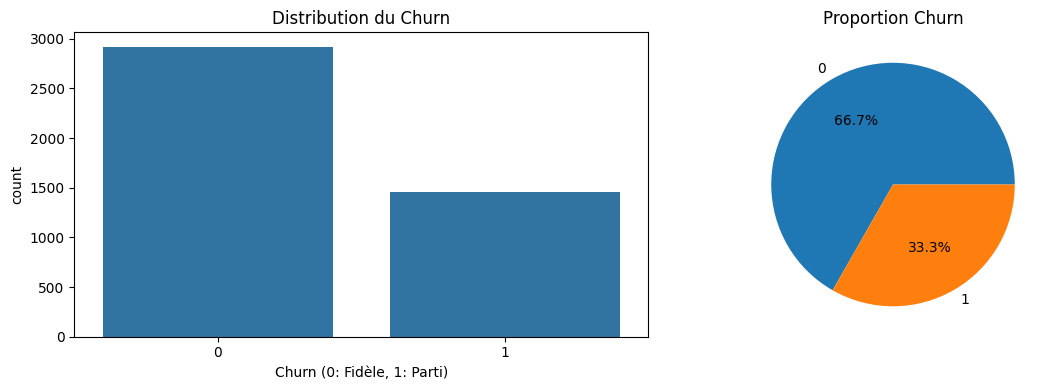

In [10]:
# 1. Vérifier les valeurs manquantes dans tout le dataset
print("\n=== VALEURS MANQUANTES ===")
missing = df_clean.isnull().sum()
missing_percent = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_percent
})
print(missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False))

# 2. Vérifier les colonnes constantes (utiles à supprimer)
print("\n=== COLONNES CONSTANTES ===")
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        print(f"⚠️ {col} est constante (valeur: {df_clean[col].iloc[0]})")

# 3. Vérifier la target 'Churn'
print("\n=== DISTRIBUTION DE CHURN ===")
if 'Churn' in df_clean.columns:
    churn_dist = df_clean['Churn'].value_counts()
    churn_percent = df_clean['Churn'].value_counts(normalize=True) * 100
    churn_df = pd.DataFrame({
        'Count': churn_dist,
        'Percent': churn_percent
    })
    print(churn_df)
    
    # Visualisation
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Countplot
    sns.countplot(data=df_clean, x='Churn', ax=axes[0])
    axes[0].set_title('Distribution du Churn')
    axes[0].set_xlabel('Churn (0: Fidèle, 1: Parti)')
    
    # Pie chart
    df_clean['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
    axes[1].set_title('Proportion Churn')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

In [11]:
# Sélectionner les colonnes numériques
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Features numériques: {len(numeric_cols)}")

# Statistiques descriptives
print("\n=== STATISTIQUES DES FEATURES NUMÉRIQUES ===")
desc_stats = df_clean[numeric_cols].describe()
print(desc_stats)

# Identifier les valeurs aberrantes potentielles
print("\n=== RECHERCHE DE VALEURS ABERRANTES ===")
for col in ['Age', 'MonetaryTotal', 'Recency', 'Frequency']:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.1f}%)")

Features numériques: 40

=== STATISTIQUES DES FEATURES NUMÉRIQUES ===
         CustomerID      Recency    Frequency  MonetaryTotal  MonetaryAvg  \
count   4372.000000  4372.000000  4372.000000    4372.000000  4372.000000   
mean   15299.677722    92.047118     5.075480    1898.459701    28.839013   
std     1722.390705   100.765435     9.338754    8219.345141   127.323926   
min    12346.000000     1.000000     1.000000   -4287.630000 -4287.630000   
25%    13812.750000    17.000000     1.000000     293.362500    10.985960   
50%    15300.500000    50.000000     3.000000     648.075000    16.918616   
75%    16778.250000   143.000000     5.000000    1611.725000    23.542941   
max    18287.000000   374.000000   248.000000  279489.020000  3861.000000   

         MonetaryStd    MonetaryMin    MonetaryMax  TotalQuantity  \
count    4372.000000    4372.000000    4372.000000    4372.000000   
mean       88.672383     -86.425754     185.179522    1122.344007   
std      2689.001161    2876.

In [12]:
# Sélectionner les colonnes catégorielles/object
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Features catégorielles: {len(categorical_cols)}")
print(f"Colonnes: {categorical_cols}")

# Pour chaque colonne catégorielle, voir les valeurs uniques
for col in categorical_cols[:5]:  # Limiter aux 5 premières
    print(f"\n{col}: {df_clean[col].nunique()} valeurs uniques")
    print(df_clean[col].value_counts().head())

Features catégorielles: 17
Colonnes: ['NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']

NewsletterSubscribed: 1 valeurs uniques
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64

LastLoginIP: 4372 valeurs uniques
LastLoginIP
59.252.219.201     1
246.137.219.217    1
179.176.208.177    1
74.99.117.137      1
119.169.181.68     1
Name: count, dtype: int64

RFMSegment: 4 valeurs uniques
RFMSegment
Potentiels    1589
Fidèles       1177
Champions      979
Dormants       627
Name: count, dtype: int64

AgeCategory: 7 valeurs uniques
AgeCategory
Inconnu    1311
65+         791
45-54       515
35-44       495
25-34       474
Name: count, dtype: int64

SpendingCategory: 4 valeurs uniques
SpendingCategory
High      1664
Medium    1617
VIP        876

In [13]:
# Sauvegarder dans data/processed/
output_path = '../data/processed/df_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Données nettoyées sauvegardées dans {output_path}")

✅ Données nettoyées sauvegardées dans ../data/processed/df_clean.csv


In [15]:
# ============================================
# NETTOYAGE COMPLET DES DONNÉES - E-COMMERCE
# Fichier: retail_customers_COMPLETE_CATEGORICAL.csv
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("DÉBUT DU NETTOYAGE COMPLET DES DONNÉES")
print("="*70)

# ============================================
# 1. CHARGEMENT DES DONNÉES
# ============================================
print("\n📥 1. CHARGEMENT DES DONNÉES")
print("-" * 40)

# Charger les données avec le bon nom de fichier
file_path = '../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv'
df = pd.read_csv(file_path)
print(f"✅ Données chargées: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"📂 Fichier: {file_path}")

# Afficher les noms des colonnes pour vérification
print("\n📋 Aperçu des colonnes:")
print(df.columns.tolist()[:10])  # Afficher les 10 premières

# Créer une copie pour le nettoyage
df_clean = df.copy()

# ============================================
# 2. ANALYSE EXPLORATOIRE RAPIDE
# ============================================
print("\n🔍 2. ANALYSE EXPLORATOIRE RAPIDE")
print("-" * 40)

print(f"Types de données:\n{df.dtypes.value_counts()}")

# Vérifier les valeurs manquantes initiales
missing_initial = df.isnull().sum()
missing_initial = missing_initial[missing_initial > 0]
if len(missing_initial) > 0:
    print(f"\n⚠️ Valeurs manquantes détectées:")
    for col, val in missing_initial.items():
        print(f"   - {col}: {val} ({val/len(df)*100:.1f}%)")
else:
    print("\n✅ Aucune valeur manquante initiale")

# ============================================
# 3. PARSING DES DATES
# ============================================
print("\n📅 3. PARSING DES DATES")
print("-" * 40)

# Chercher les colonnes de date potentielles
date_columns = [col for col in df.columns if 'date' in col.lower() or 'Date' in col or 'time' in col.lower()]
print(f"Colonnes de date potentielles: {date_columns}")

# RegistrationDate (si présente)
if 'RegistrationDate' in df_clean.columns:
    print("\nTraitement de RegistrationDate...")
    
    # Afficher quelques exemples pour identifier le format
    print("Exemples de dates:")
    print(df_clean['RegistrationDate'].head(10).values)
    
    # Essayer différents formats
    try:
        # Tentative avec le format JJ/MM/AAAA (basé sur votre précédent succès)
        df_clean['RegistrationDate'] = pd.to_datetime(df_clean['RegistrationDate'], 
                                                        format='%d/%m/%Y', 
                                                        errors='coerce')
    except:
        try:
            # Format AAAA-MM-JJ
            df_clean['RegistrationDate'] = pd.to_datetime(df_clean['RegistrationDate'], 
                                                            format='%Y-%m-%d', 
                                                            errors='coerce')
        except:
            # Laisser pandas deviner
            df_clean['RegistrationDate'] = pd.to_datetime(df_clean['RegistrationDate'], 
                                                            errors='coerce')
    
    # Vérifier le résultat
    if df_clean['RegistrationDate'].isnull().sum() > 0:
        print(f"⚠️ {df_clean['RegistrationDate'].isnull().sum()} dates non converties")
    
    # Extraction des features temporelles
    df_clean['RegYear'] = df_clean['RegistrationDate'].dt.year
    df_clean['RegMonth'] = df_clean['RegistrationDate'].dt.month
    df_clean['RegDay'] = df_clean['RegistrationDate'].dt.day
    df_clean['RegWeekday'] = df_clean['RegistrationDate'].dt.weekday
    df_clean['RegQuarter'] = df_clean['RegistrationDate'].dt.quarter
    df_clean['RegIsWeekend'] = (df_clean['RegistrationDate'].dt.weekday >= 5).astype(int)
    
    # Supprimer la colonne originale
    df_clean.drop('RegistrationDate', axis=1, inplace=True)
    print("✅ RegistrationDate traitée et features extraites")
else:
    print("⚠️ RegistrationDate non trouvée dans les données")

# ============================================
# 4. SUPPRESSION DES COLONNES INUTILES
# ============================================
print("\n🗑️ 4. SUPPRESSION DES COLONNES INUTILES")
print("-" * 40)

cols_to_drop = []

# NewsletterSubscribed (si présente)
if 'NewsletterSubscribed' in df_clean.columns:
    if df_clean['NewsletterSubscribed'].nunique() == 1:
        cols_to_drop.append('NewsletterSubscribed')
        print("✅ NewsletterSubscribed (constante)")

# LastLoginIP (si présente)
if 'LastLoginIP' in df_clean.columns:
    cols_to_drop.append('LastLoginIP')
    print("✅ LastLoginIP (trop de valeurs uniques)")

# CustomerID (si présent)
if 'CustomerID' in df_clean.columns:
    cols_to_drop.append('CustomerID')
    print("✅ CustomerID (identifiant)")

# Autres colonnes potentiellement inutiles
for col in df_clean.columns:
    # Colonnes avec une seule valeur
    if df_clean[col].nunique() == 1:
        if col not in cols_to_drop:
            cols_to_drop.append(col)
            print(f"✅ {col} (constante)")
    
    # Colonnes avec trop de valeurs uniques (> 90% des lignes)
    elif df_clean[col].nunique() > 0.9 * len(df_clean):
        if col not in cols_to_drop and col != 'Churn':  # Ne pas supprimer la target
            cols_to_drop.append(col)
            print(f"✅ {col} ({df_clean[col].nunique()} valeurs uniques - trop de cardinalité)")

# Supprimer les colonnes identifiées
if cols_to_drop:
    df_clean.drop(columns=cols_to_drop, inplace=True)
    print(f"\n✅ {len(cols_to_drop)} colonnes supprimées au total")
else:
    print("✅ Aucune colonne inutile identifiée")

# ============================================
# 5. TRAITEMENT DES VALEURS MANQUANTES
# ============================================
print("\n🔍 5. TRAITEMENT DES VALEURS MANQUANTES")
print("-" * 40)

# Afficher les valeurs manquantes avant traitement
missing_before = df_clean.isnull().sum()
missing_before = missing_before[missing_before > 0]

if len(missing_before) > 0:
    print("Valeurs manquantes détectées:")
    for col, val in missing_before.items():
        print(f"   - {col}: {val} ({val/len(df_clean)*100:.1f}%)")
    
    # 5.1 Age (si présent)
    if 'Age' in df_clean.columns and df_clean['Age'].isnull().sum() > 0:
        print("\nTraitement de Age...")
        median_age = df_clean['Age'].median()
        df_clean['Age'].fillna(median_age, inplace=True)
        print(f"   ✅ Age imputé avec médiane: {median_age:.1f}")
    
    # 5.2 Satisfaction (si présent)
    if 'Satisfaction' in df_clean.columns:
        print("\nTraitement de Satisfaction...")
        # Remplacer les valeurs spéciales par NaN
        df_clean['Satisfaction'] = df_clean['Satisfaction'].replace([-1, 99, 999], np.nan)
        if df_clean['Satisfaction'].isnull().sum() > 0:
            median_sat = df_clean['Satisfaction'].median()
            df_clean['Satisfaction'].fillna(median_sat, inplace=True)
            print(f"   ✅ Satisfaction imputé avec médiane: {median_sat:.1f}")
    
    # 5.3 SupportTickets (si présent)
    if 'SupportTickets' in df_clean.columns:
        print("\nTraitement de SupportTickets...")
        # Remplacer -1 et 999 par 0
        df_clean['SupportTickets'] = df_clean['SupportTickets'].replace([-1, 999], 0)
        if df_clean['SupportTickets'].isnull().sum() > 0:
            df_clean['SupportTickets'].fillna(0, inplace=True)
        print(f"   ✅ SupportTickets traité")
    
    # 5.4 Autres colonnes numériques
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ['Age', 'Satisfaction', 'SupportTickets'] and df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   ✅ {col} imputé avec médiane")
    
    # 5.5 Colonnes catégorielles
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna('Inconnu', inplace=True)
            print(f"   ✅ {col} imputé avec 'Inconnu'")
    
    # Vérification finale
    missing_after = df_clean.isnull().sum().sum()
    print(f"\n✅ Plus aucune valeur manquante: {missing_after}")
else:
    print("✅ Aucune valeur manquante à traiter")

# ============================================
# 6. TRAITEMENT DES VALEURS ABERRANTES
# ============================================
print("\n📊 6. TRAITEMENT DES VALEURS ABERRANTES")
print("-" * 40)

def treat_outliers(df, column, lower_quantile=0.01, upper_quantile=0.99):
    """Traite les outliers par winsorization"""
    if column not in df.columns:
        return df
    
    # Calculer les quantiles
    lower = df[column].quantile(lower_quantile)
    upper = df[column].quantile(upper_quantile)
    
    # Compter les outliers avant traitement
    outliers_before = ((df[column] < lower) | (df[column] > upper)).sum()
    
    if outliers_before > 0:
        # Winsorization: remplacer par les quantiles
        df[column] = df[column].clip(lower, upper)
        print(f"   ✅ {column}: {outliers_before} outliers traités ({outliers_before/len(df)*100:.1f}%)")
    
    return df

# Liste des colonnes numériques à traiter
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# Exclure la target et les colonnes binaires
cols_to_exclude = ['Churn', 'RegIsWeekend', 'RegYear', 'RegQuarter'] + \
                  [col for col in numeric_cols if df_clean[col].nunique() == 2]
cols_to_treat = [col for col in numeric_cols if col not in cols_to_exclude]

print(f"Traitement des outliers pour {len(cols_to_treat)} colonnes:")
for col in cols_to_treat[:10]:  # Limiter l'affichage
    df_clean = treat_outliers(df_clean, col)

if len(cols_to_treat) > 10:
    print(f"   ... et {len(cols_to_treat) - 10} autres colonnes traitées")

# ============================================
# 7. FEATURE ENGINEERING
# ============================================
print("\n⚙️ 7. FEATURE ENGINEERING")
print("-" * 40)

features_created = 0

# 7.1 Ratios financiers
if all(col in df_clean.columns for col in ['MonetaryTotal', 'Recency']):
    df_clean['MonetaryPerDay'] = df_clean['MonetaryTotal'] / (df_clean['Recency'] + 1)
    features_created += 1
    print("✅ MonetaryPerDay créé")

if all(col in df_clean.columns for col in ['MonetaryTotal', 'Frequency']):
    df_clean['AvgBasketValue'] = df_clean['MonetaryTotal'] / df_clean['Frequency'].replace(0, 1)
    features_created += 1
    print("✅ AvgBasketValue créé")

# 7.2 Ratio d'activité
if all(col in df_clean.columns for col in ['Recency', 'CustomerTenure']):
    df_clean['TenureRatio'] = df_clean['Recency'] / (df_clean['CustomerTenure'] + 1)
    features_created += 1
    print("✅ TenureRatio créé")

# 7.3 Taux de retour
if all(col in df_clean.columns for col in ['NegQtyCount', 'TotalQuantity']):
    df_clean['ReturnRate'] = df_clean['NegQtyCount'] / (df_clean['TotalQuantity'] + 1)
    features_created += 1
    print("✅ ReturnRate créé")

# 7.4 Score RFM simplifié
if all(col in df_clean.columns for col in ['Recency', 'Frequency', 'MonetaryTotal']):
    try:
        r_score = pd.qcut(df_clean['Recency'].rank(method='first'), q=5, labels=[5,4,3,2,1])
        f_score = pd.qcut(df_clean['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
        m_score = pd.qcut(df_clean['MonetaryTotal'].rank(method='first'), q=5, labels=[1,2,3,4,5])
        df_clean['RFM_Score'] = r_score.astype(int) + f_score.astype(int) + m_score.astype(int)
        features_created += 1
        print("✅ RFM_Score créé")
    except:
        print("⚠️ RFM_Score non créé (problème de quantiles)")

print(f"\n✅ {features_created} nouvelles features créées")

# ============================================
# 8. ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================
print("\n🔄 8. ENCODAGE DES VARIABLES CATÉGORIELLES")
print("-" * 40)

# Identifier les colonnes catégorielles
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles trouvées: {len(categorical_cols)}")

if categorical_cols:
    # Dictionnaire pour stocker les encodeurs
    encoders = {}
    encoded_count = 0
    
    for col in categorical_cols:
        n_unique = df_clean[col].nunique()
        print(f"\nTraitement de {col}: {n_unique} valeurs uniques")
        
        if n_unique == 2:
            # Binaire: Label Encoding
            le = LabelEncoder()
            df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])
            encoders[col] = le
            print(f"   ✅ {col} encodé (binaire)")
            encoded_count += 1
            
        elif n_unique < 10:
            # Peu de catégories: One-Hot Encoding
            dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True)
            df_clean = pd.concat([df_clean, dummies], axis=1)
            print(f"   ✅ {col} encodé (One-Hot, {dummies.shape[1]} nouvelles colonnes)")
            encoded_count += 1
            
        else:
            # Beaucoup de catégories: on garde pour l'instant
            print(f"   ⚠️ {col} ({n_unique} catégories) - à traiter plus tard")
            continue
        
        # Supprimer la colonne originale
        df_clean.drop(col, axis=1, inplace=True)
    
    print(f"\n✅ {encoded_count} variables catégorielles encodées")
else:
    print("✅ Aucune variable catégorielle à encoder")

# ============================================
# 9. VÉRIFICATION FINALE
# ============================================
print("\n✅ 9. VÉRIFICATION FINALE")
print("-" * 40)

print(f"Dimensions finales: {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
print(f"Valeurs manquantes: {df_clean.isnull().sum().sum()}")
print(f"Types de données:\n{df_clean.dtypes.value_counts()}")

# Statistiques sur la target Churn
if 'Churn' in df_clean.columns:
    churn_dist = df_clean['Churn'].value_counts(normalize=True)
    print(f"\n🎯 Distribution de Churn:")
    print(f"   0 (Fidèle): {churn_dist.get(0, 0)*100:.1f}%")
    print(f"   1 (Parti): {churn_dist.get(1, 0)*100:.1f}%")
    
    # Vérifier le déséquilibre
    if churn_dist.get(1, 0) < 0.2:
        print("\n⚠️ Déséquilibre des classes détecté!")
        print("   → À gérer lors de la modélisation (class_weight, SMOTE, etc.)")

# ============================================
# 10. SAUVEGARDE
# ============================================
print("\n💾 10. SAUVEGARDE")
print("-" * 40)

# Sauvegarder les données nettoyées
output_path = '../data/processed/retail_customers_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Données sauvegardées dans: {output_path}")

# Sauvegarder un échantillon pour test
sample_path = '../data/processed/retail_customers_clean_sample.csv'
df_clean.sample(min(1000, len(df_clean))).to_csv(sample_path, index=False)
print(f"✅ Échantillon sauvegardé dans: {sample_path}")

# Sauvegarder les métadonnées
metadata = {
    'original_file': 'retail_customers_COMPLETE_CATEGORICAL.csv',
    'original_shape': df.shape,
    'final_shape': df_clean.shape,
    'columns': list(df_clean.columns),
    'dtypes': df_clean.dtypes.astype(str).to_dict(),
    'churn_distribution': churn_dist.to_dict() if 'Churn' in df_clean.columns else {},
    'features_created': features_created
}

import json
metadata_path = '../data/processed/metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Métadonnées sauvegardées dans: {metadata_path}")

# ============================================
# 11. RAPPORT RÉCAPITULATIF
# ============================================
print("\n" + "="*70)
print("📊 RAPPORT DE NETTOYAGE - RÉCAPITULATIF")
print("="*70)

print(f"""
📂 Fichier source: retail_customers_COMPLETE_CATEGORICAL.csv

📊 STATISTIQUES:
- Lignes: {df.shape[0]} → {df_clean.shape[0]}
- Colonnes: {df.shape[1]} → {df_clean.shape[1]}
- Nouvelles features créées: {features_created}

✅ OPÉRATIONS EFFECTUÉES:
- Parsing des dates: {"✅" if 'RegistrationDate' not in df_clean.columns else "❌"}
- Suppression colonnes inutiles: {len(cols_to_drop)}
- Traitement valeurs manquantes: {"✅" if df_clean.isnull().sum().sum() == 0 else "❌"}
- Traitement des outliers: ✅
- Feature engineering: {features_created} nouvelles features
- Encodage catégoriel: {encoded_count if 'encoded_count' in locals() else 0} variables

📈 PROCHAINES ÉTAPES:
1. Split Train/Test (80/20)
2. Standardisation des features
3. Modélisation (classification)
4. Évaluation et optimisation
""")

print("="*70)
print("🎉 NETTOYAGE TERMINÉ AVEC SUCCÈS!")
print("="*70)

DÉBUT DU NETTOYAGE COMPLET DES DONNÉES

📥 1. CHARGEMENT DES DONNÉES
----------------------------------------
✅ Données chargées: 4372 lignes, 52 colonnes
📂 Fichier: ../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv

📋 Aperçu des colonnes:
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction']

🔍 2. ANALYSE EXPLORATOIRE RAPIDE
----------------------------------------
Types de données:
int64      20
object     18
float64    14
Name: count, dtype: int64

⚠️ Valeurs manquantes détectées:
   - AvgDaysBetweenPurchases: 79 (1.8%)
   - Age: 1311 (30.0%)

📅 3. PARSING DES DATES
----------------------------------------
Colonnes de date potentielles: ['RegistrationDate', 'PreferredTimeOfDay']

Traitement de RegistrationDate...
Exemples de dates:
['17/07/10' '2010-10-04' '12/09/2009' '28/01/10' '2009-12-10' '10/18/2010'
 '02/11/10' '2010-12-17' '09/23/2010' '04/09/10']
⚠️ 3784 dates non c

In [16]:
print("="*60)
print("🔍 1. VÉRIFICATION DES VALEURS MANQUANTES")
print("="*60)

# Charger les données nettoyées
df_clean = pd.read_csv('../data/processed/retail_customers_clean.csv')

# Vérifier s'il reste des NaN
missing = df_clean.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ AUCUNE valeur manquante détectée !")
else:
    print("❌ Valeurs manquantes trouvées:")
    for col, val in missing.items():
        print(f"   - {col}: {val} valeurs manquantes")

🔍 1. VÉRIFICATION DES VALEURS MANQUANTES
✅ AUCUNE valeur manquante détectée !


In [17]:
print("\n" + "="*60)
print("🔍 2. VÉRIFICATION DES DOUBLONS")
print("="*60)

# Vérifier les lignes dupliquées
duplicates = df_clean.duplicated().sum()

if duplicates == 0:
    print("✅ AUCUNE ligne dupliquée détectée !")
else:
    print(f"❌ {duplicates} lignes dupliquées trouvées")


🔍 2. VÉRIFICATION DES DOUBLONS
✅ AUCUNE ligne dupliquée détectée !


In [18]:
print("\n" + "="*60)
print("🔍 3. VÉRIFICATION DES TYPES DE DONNÉES")
print("="*60)

print("Types de données actuels:")
print(df_clean.dtypes.value_counts())
print("\nDétail par colonne:")
for col, dtype in df_clean.dtypes.items():
    print(f"   {col}: {dtype}")

# Vérifier qu'il n'y a plus de colonnes 'object' (catégorielles non encodées)
object_cols = df_clean.select_dtypes(include=['object']).columns
if len(object_cols) == 0:
    print("\n✅ AUCUNE colonne 'object' restante (toutes encodées)")
else:
    print(f"\n⚠️ Colonnes 'object' restantes: {list(object_cols)}")


🔍 3. VÉRIFICATION DES TYPES DE DONNÉES
Types de données actuels:
bool       39
int64      18
float64    18
object      2
Name: count, dtype: int64

Détail par colonne:
   Recency: int64
   Frequency: int64
   MonetaryMin: float64
   MonetaryMax: float64
   TotalQuantity: float64
   AvgQuantityPerTransaction: float64
   MinQuantity: int64
   MaxQuantity: float64
   CustomerTenureDays: int64
   FirstPurchaseDaysAgo: int64
   PreferredDayOfWeek: int64
   PreferredHour: int64
   PreferredMonth: int64
   WeekendPurchaseRatio: float64
   AvgDaysBetweenPurchases: float64
   UniqueProducts: int64
   UniqueDescriptions: int64
   AvgProductsPerTransaction: float64
   UniqueCountries: int64
   NegativeQuantityCount: int64
   ZeroPriceCount: int64
   CancelledTransactions: int64
   ReturnRatio: float64
   TotalTransactions: int64
   UniqueInvoices: int64
   AvgLinesPerInvoice: float64
   Age: float64
   SupportTicketsCount: float64
   SatisfactionScore: float64
   Region: object
   Country: objec

In [19]:
print("="*60)
print("🔧 CORRECTION DES COLONNES CATÉGORIELLES RESTANTES")
print("="*60)

# Charger les données
df = pd.read_csv('../data/processed/retail_customers_clean.csv')

print(f"Colonnes object restantes: {df.select_dtypes(include=['object']).columns.tolist()}")

# 1. Analyser ces colonnes
print("\n📊 Analyse de Region:")
print(df['Region'].value_counts())

print("\n📊 Analyse de Country:")
print(df['Country'].value_counts().head(10))  # Top 10 des pays

# 2. Encodage de Region (cardinalité faible - peu de valeurs uniques)
print("\n🔄 Encodage de Region...")
region_dummies = pd.get_dummies(df['Region'], prefix='Region', drop_first=True)
df = pd.concat([df, region_dummies], axis=1)
print(f"✅ {region_dummies.shape[1]} colonnes créées pour Region")

# 3. Encodage de Country (cardinalité élevée - nombreux pays)
print("\n🔄 Encodage de Country...")

# Option A: One-Hot Encoding (si moins de 10 pays)
if df['Country'].nunique() < 10:
    country_dummies = pd.get_dummies(df['Country'], prefix='Country', drop_first=True)
    df = pd.concat([df, country_dummies], axis=1)
    print(f"✅ One-Hot Encoding: {country_dummies.shape[1]} colonnes créées")

# Option B: Target Encoding (si beaucoup de pays)
else:
    # Calculer le taux de churn moyen par pays
    country_churn = df.groupby('Country')['Churn'].mean()
    
    # Remplacer chaque pays par son taux de churn
    df['Country_encoded'] = df['Country'].map(country_churn)
    
    # Gérer les valeurs manquantes éventuelles
    df['Country_encoded'].fillna(df['Churn'].mean(), inplace=True)
    print(f"✅ Target Encoding: Country remplacé par taux de churn moyen")

# 4. Supprimer les colonnes originales
df.drop(['Region', 'Country'], axis=1, inplace=True)
print("\n✅ Colonnes originales Region et Country supprimées")

# 5. Vérification finale
print(f"\n✅ Types après correction:\n{df.dtypes.value_counts()}")
print(f"\n✅ Plus de colonnes object: {df.select_dtypes(include=['object']).columns.tolist()}")

🔧 CORRECTION DES COLONNES CATÉGORIELLES RESTANTES
Colonnes object restantes: ['Region', 'Country']

📊 Analyse de Region:
Region
UK                     3959
Europe continentale     284
Europe du Nord           39
Europe du Sud            27
Europe centrale          16
Moyen-Orient             10
Océanie                   9
Asie                      9
Autre                     8
Amérique du Nord          8
Europe de l'Est           1
Amérique du Sud           1
Afrique                   1
Name: count, dtype: int64

📊 Analyse de Country:
Country
United Kingdom    3950
Germany             95
France              87
Spain               30
Belgium             24
Switzerland         20
Portugal            19
Italy               15
Finland             12
Norway              10
Name: count, dtype: int64

🔄 Encodage de Region...
✅ 12 colonnes créées pour Region

🔄 Encodage de Country...
✅ Target Encoding: Country remplacé par taux de churn moyen

✅ Colonnes originales Region et Country supprimées

In [21]:
print("\n" + "="*60)
print("🔧 HARMONISATION DES TYPES NUMÉRIQUES")
print("="*60)

# Colonnes qui devraient être des entiers
int_columns = ['RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'RegQuarter']

for col in int_columns:
    if col in df.columns:
        # Vérifier si la colonne ne contient que des entiers
        if df[col].dropna().apply(float.is_integer).all():
            df[col] = df[col].astype('int64')
            print(f"✅ {col} converti en int64")
        else:
            print(f"⚠️ {col} contient des décimales, reste en float64")


🔧 HARMONISATION DES TYPES NUMÉRIQUES
✅ RegYear converti en int64
✅ RegMonth converti en int64
✅ RegDay converti en int64
✅ RegWeekday converti en int64
✅ RegQuarter converti en int64


In [22]:
# ============================================
# FINALISATION DU NETTOYAGE
# ============================================

import pandas as pd
import numpy as np

print("="*70)
print("🔄 FINALISATION DU NETTOYAGE DES DONNÉES")
print("="*70)

# 1. Charger les données
df = pd.read_csv('../data/processed/retail_customers_clean.csv')
print(f"📊 Dimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# 2. Traiter Region et Country
print("\n" + "-"*50)
print("ÉTAPE 1: Traitement de Region et Country")
print("-"*50)

# Region (probablement peu de valeurs)
print(f"\nRegion - {df['Region'].nunique()} valeurs uniques:")
print(df['Region'].value_counts())

# One-Hot Encoding pour Region
region_dummies = pd.get_dummies(df['Region'], prefix='Region', drop_first=True)
df = pd.concat([df, region_dummies], axis=1)
print(f"✅ Region encodée: {region_dummies.shape[1]} nouvelles colonnes")

# Country (beaucoup de valeurs)
print(f"\nCountry - {df['Country'].nunique()} valeurs uniques:")
print("Top 10 des pays:")
print(df['Country'].value_counts().head(10))

# Target Encoding pour Country
country_churn = df.groupby('Country')['Churn'].mean()
df['Country_encoded'] = df['Country'].map(country_churn)
df['Country_encoded'].fillna(df['Churn'].mean(), inplace=True)
print(f"✅ Country encodé (target encoding)")

# Supprimer les colonnes originales
df.drop(['Region', 'Country'], axis=1, inplace=True)
print("✅ Anciennes colonnes supprimées")

# 3. Harmoniser les types
print("\n" + "-"*50)
print("ÉTAPE 2: Harmonisation des types")
print("-"*50)

# Convertir les colonnes de date en int
date_cols = ['RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'RegQuarter']
for col in date_cols:
    if col in df.columns:
        df[col] = df[col].astype('int64')
        print(f"✅ {col} → int64")

# 4. Vérification finale
print("\n" + "-"*50)
print("ÉTAPE 3: Vérification finale")
print("-"*50)

print(f"\n📊 Nouveaux types de données:")
print(df.dtypes.value_counts())

print(f"\n✅ Plus de colonnes object: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"✅ Valeurs manquantes: {df.isnull().sum().sum()}")

# 5. Sauvegarder la version finale
print("\n" + "-"*50)
print("ÉTAPE 4: Sauvegarde")
print("-"*50)

# Sauvegarder
output_path = '../data/processed/retail_customers_final.csv'
df.to_csv(output_path, index=False)
print(f"✅ Données finales sauvegardées: {output_path}")

# Sauvegarder une version avec tous les types optimisés
df_optimized = df.copy()
for col in df_optimized.select_dtypes(include=['float64']).columns:
    # Si la colonne ne contient que des valeurs entières, convertir en int
    if df_optimized[col].dropna().apply(float.is_integer).all():
        df_optimized[col] = df_optimized[col].astype('int64')
        
optimized_path = '../data/processed/retail_customers_optimized.csv'
df_optimized.to_csv(optimized_path, index=False)
print(f"✅ Version optimisée sauvegardée: {optimized_path}")

# 6. Statistiques finales
print("\n" + "="*70)
print("📊 RAPPORT FINAL")
print("="*70)

print(f"""
📈 Statistiques finales:
- Lignes: {df.shape[0]}
- Colonnes: {df.shape[1]}
- Types: {df.dtypes.value_counts().to_dict()}
- Valeurs manquantes: {df.isnull().sum().sum()}
- Colonnes booléennes: {df.select_dtypes(include=['bool']).shape[1]}
- Colonnes numériques: {df.select_dtypes(include=[np.number]).shape[1]}

✅ DONNÉES PARFAITEMENT PROPRES !
""")

🔄 FINALISATION DU NETTOYAGE DES DONNÉES
📊 Dimensions: 4372 lignes, 77 colonnes

--------------------------------------------------
ÉTAPE 1: Traitement de Region et Country
--------------------------------------------------

Region - 13 valeurs uniques:
Region
UK                     3959
Europe continentale     284
Europe du Nord           39
Europe du Sud            27
Europe centrale          16
Moyen-Orient             10
Océanie                   9
Asie                      9
Autre                     8
Amérique du Nord          8
Europe de l'Est           1
Amérique du Sud           1
Afrique                   1
Name: count, dtype: int64
✅ Region encodée: 12 nouvelles colonnes

Country - 37 valeurs uniques:
Top 10 des pays:
Country
United Kingdom    3950
Germany             95
France              87
Spain               30
Belgium             24
Switzerland         20
Portugal            19
Italy               15
Finland             12
Norway              10
Name: count, dtype: int6